## Exercise Project 1 -- Linear Regression
### Dataset: [NYC Housing Prices](https://www.kaggle.com/datasets/ishank2005/nyc-housing-prices-csv)

<br>
<br>


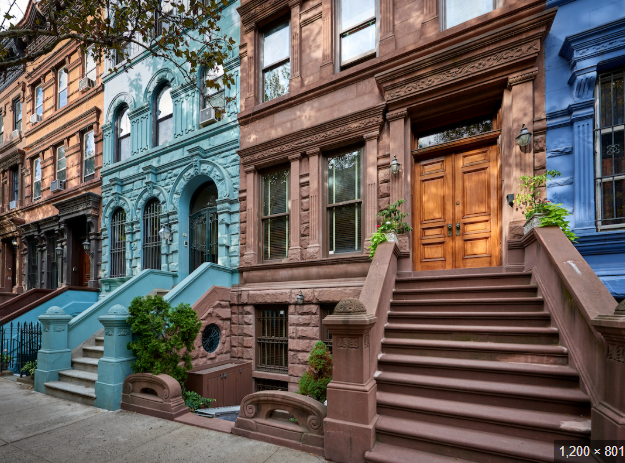

<br>

<br>

##### Shape: `34k rows, 19 columns`

##### Target Variable: `sale_price`

##### Method: `Linear Regression`

##### Extra Tools: `Mlflow`

##### Column Descriptions (Complete):

| Column        | Description |
|--------------|-------------|
| borough_x    | *Borough code associated with the property sale record, sourced from the NYC Citywide Rolling Sales dataset.* |
| block        | *NYC tax block identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| lot          | *NYC tax lot identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| sale_price   | *Recorded sale price of the property transaction in US dollars. Non-arm’s-length and invalid transactions have been removed.* |
| zip_code     | *ZIP code of the property as recorded in the sales transaction data.* |
| borough_y    | *Borough code associated with the property tax lot, sourced from the PLUTO building dataset.* |
| yearbuilt    | *Year in which the primary structure on the tax lot was originally constructed.* |
| lotarea      | *Total land area of the tax lot, measured in square feet.* |
| bldgarea     | *Total gross building floor area on the tax lot, measured in square feet.* |
| resarea      | *Portion of the building floor area used for residential purposes, measured in square feet.* |
| comarea      | *Total commercial floor area within the building, measured in square feet.* |
| unitsres     | *Number of residential housing units on the tax lot.* |
| unitstotal   | *Total number of units on the tax lot, including residential and non-residential units.* |
| numfloors    | *Number of floors in the primary building on the tax lot.* |
| latitude     | *Latitude coordinate of the property location, expressed in decimal degrees.* |
| longitude    | *Longitude coordinate of the property location, expressed in decimal degrees.* |
| landuse      | *Numeric land use category code describing the primary use of the property (e.g., residential, commercial, mixed-use).* |
| bldgclass    | *NYC building class code indicating the structural and usage classification of the property.* |
| building_age | *Age of the building in years at the time of sale, calculated as sale year minus year built.* |


<br>
<br>



---

### Code

In [1]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder
import mlflow

# Reading the dataframe and storing it.
df = pd.read_csv("datasets/nyc_housing.csv")
df.head(5)

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0


## Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation|
|3| ML Implementation|
|4|Tester Row Values|
|5| Personal Analysis |
|6|Model Application|
|7| Advanced Tasks|

The following cleaning process will consist of handling missing values, duplicates, and dropping likely multi-colinearity (co-cardinality) features.
It also handles some isolated features for `bldgclass` before putting it into `OneHotEncoder`

#### Checking The Dataframe Shape

In [2]:
# Checking the amount of columns and rows.
df.shape

# That seems like a reasonable amount of data. Lots to work with.

(34439, 19)

#### Handling Missing Values

In [3]:
# Checking for missing values
df.isna().sum()

# A small amount of rows have missing values. 
# Getting rid of all the NaN will be trivial 200/34000 = .5% of the data. Not timeseries, so it's fine.

# Dropping nan values.
df = df.dropna()

#### Handling Duplicates

In [4]:
# Checking for duplicates
df.duplicated().value_counts()

# Some duplicates do exist. We can safely get rid of these.

False    33204
True       999
Name: count, dtype: int64

In [5]:
# Dropping the duplicate rows.
df = df.drop_duplicates()

##### Dropping Columns

Here, we'll be dropping some of the columns which we know we won't be using. We are dropping columns that have the following:

|Features to drop| Description/Why|
|---|---|
|High collinearity/ high multicollinearity| one feature is dependent on another|
|Outlier/isolated cases|If there's only 4 buildings that have a specific category, they are likely outliers|




In [6]:
# Dropping co-dependent/high collinearity columns
df = df.drop(["borough_x",       # Related to borough_y
                'latitude',      # Probably just noise in the data.
                'longitude',     # Probably just noise in the data.
                'yearbuilt',     # This is co-dependent with `buildingage`
                'comarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'resarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'lot',           # We have borough_y. This is too specific, you'd have distributions of 1 unit being in lot ABC, hardly statistical.
                'block',         # We have borough_y, too specific. We cant have 3 units in a block be a statistical weight for an ML model.
                'zip_code',      # Too specific, it'll affect distribution.
                'landuse',       # This is often co-dependent with bldgclass (D4 bldgclass = landuse 3 for example).      
], axis=1)

# `borough_y` and `bldglclass` is categorical, we'll convert this to numbers. 
df.head(3)


,sale_price,borough_y,lotarea,bldgarea,unitsres,unitstotal,numfloors,bldgclass,building_age
0,280000,MN,2404.0,6875.0,18.0,18.0,5.0,C6,125.0
1,2000000,MN,1919.0,7810.0,8.0,10.0,5.0,C4,125.0
2,3400000,MN,2150.0,6152.0,8.0,9.0,5.0,C7,105.0


##### Categorical Feature Isolated Case Elimination

##### `bldgclass`

In [7]:
# Let's check the value counts of the categorical variables.

# In `bldgclass`, there are isolated cases there just isn't enough data
# to give a fair statistical weight to them.
value_counts = df['bldgclass'].value_counts().sort_values(ascending=True)
value_counts
# We need to get rid of some of these isolated cases.

bldgclass
I7       1
H8       1
I4       1
P7       1
P3       1
      ... 
B2    2523
B1    2613
A5    3314
A1    4037
D4    6079
Name: count, Length: 109, dtype: int64

In [8]:
# This eliminates any building classes that have less than 20 values. 
df = df[df['bldgclass'].isin(value_counts[value_counts >= 20].index)]

# REASONING:
# For example: What if `bldgclass` has only one `G7` row value and also that it was an unusual, extreme case that did not fit
# the real world well, what would happen?

# Well, now I'm empowering that one-particular case with it's own column and inaccurate
# weight value for my ML model. Let's avoid that.


##### `borough_y`

In [9]:
# Let's check the other categorical feature, `borough_y`
df['borough_y'].value_counts()

# This seems ok! plenty of data to work with.

borough_y
QN    12619
BK     9532
SI     3842
MN     3717
BX     3221
Name: count, dtype: int64

##### Turning Categorical Columns into Numbers

In [10]:
# List of columns to convert to numbers.
categorical_columns = ["borough_y",  # Example values: MN, ME, BK
                       "bldgclass",  # Example values: C6, K4, C8
                       ]


# Converts columns into binary, separate columns.
for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)

---



### Transformation

|Step|Description|
|---|---|
|1| Data Cleaning |
|2|<bold style="background:yellow;color:black;"> Transformation </bold>|
|3| ML Implementation|
|4| Tester Row Values|
|5| Personal Analysis |
|6| Model Application|
|7| Advanced Tasks|


####  Target Outlier & Skew Elimination

For this approach, we will use a before-after combination of histplots that displays how we made changes to the target variable distribution.

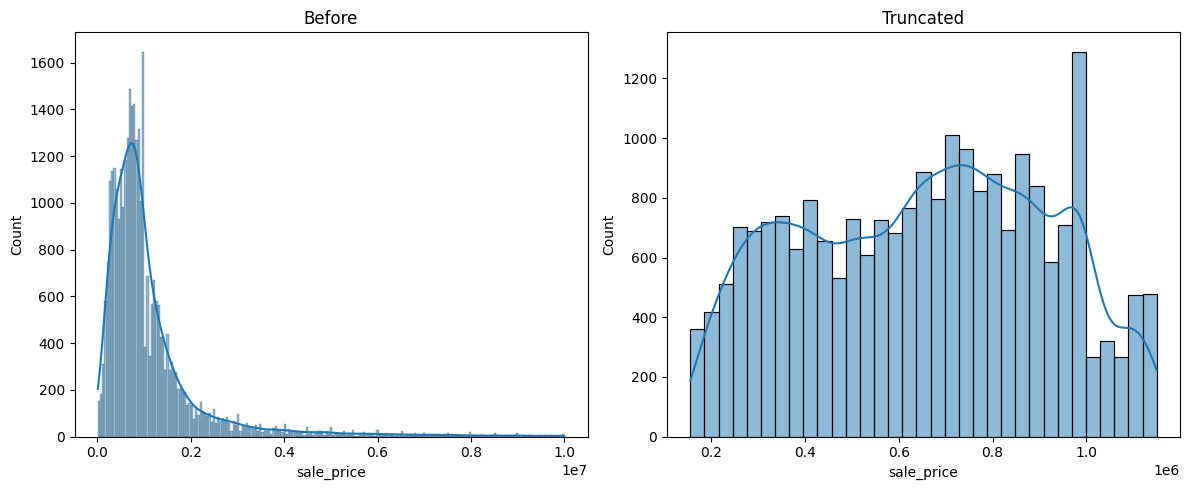

Rows left: 22490


In [11]:
# Target variable cutoffs (these constants show up in MLFLOW to track parameters of the run).
y_trunc_floor = 0.02
y_trunc_ceiling = 0.70

# Creates three canvases for histplots to show my work.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# HISTPLOT 0, no changes to distribution
sns.histplot(df, x='sale_price', ax=axes[0], kde=True)

# Truncating the Y variable.
df = df[
    (df['sale_price'] >= df['sale_price'].quantile(q=y_trunc_floor)) &
    (df['sale_price'] <= df['sale_price'].quantile(q=y_trunc_ceiling))
    ]

# HISTPLOT 1, truncated distribution
sns.histplot(df, x='sale_price', ax=axes[1], kde=True)

# Histplot titles
axes[0].set_title("Before")
axes[1].set_title("Truncated")
plt.tight_layout()
plt.show()

# It's not perfect, but it will do!

# SANITY CHECK:
# Let's check how many rows we have left.
print(f"Rows left: {df.shape[0]}")


<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<h3>Note</h3>

I've tried different methods to reduce the skew, such as: 

* Logarithmic Transformation
* Square Transformation
* Auto-truncation methods (such as the first method in Tuomas' lecture notes, which eliminates values > 3 stdevs away)

None of these methods worked as well as this manual trunctation method (both MAE and R^2 were negatively affected). Which is interesting, since the distribution
was remarkably more normal with some of these methods. 


<strong style='color:orange ; background-color:black;'> KISS (Keep it stupid simple), I suppose! </strong>

</div>

#### Quick-check -- Pearson Correlation Matrix

Since our model will be `LinearRegression`, we'll only be using Pearson correlation to check for features since it is almost a perfect indicator for feature importance
in linearity.


<Axes: >

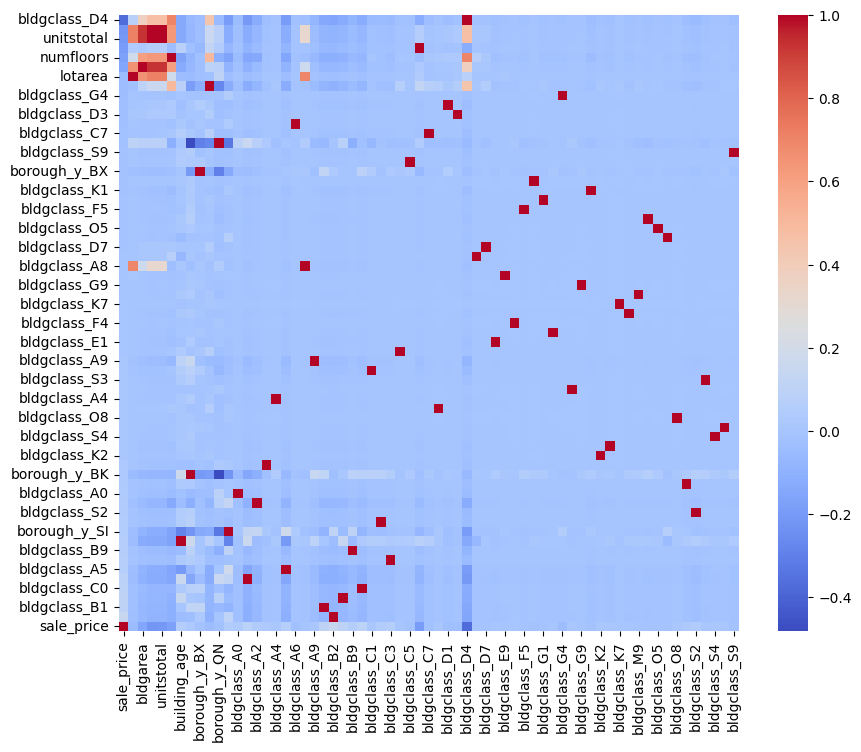

In [12]:
# Pearson correlation heatmap (matrix)
correlations = df.corr( method='pearson',numeric_only=True).sort_values(by='sale_price')
plt.figure(figsize=(10,8))
sns.heatmap(correlations, cmap='coolwarm')

#### 

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<h3>Note</h3>

Similarly, to the target_distribution case, I have also tried many different combinations of features to see what works, but nothing worked as well than simply using all of the features in the correlation matrix above.

I am not entirely sure why actually, I should research why that might be the case. I think it may have to do with the nature of `LinearRegression` being, well... Linear!

</div>

---

### ML Implementation

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|<bold style="background:yellow;color:black;"> ML Implementation</bold>|
|4| Tester Row Values|
|5| Personal Analysis|
|6| Model Application|
|7| Advanced Tasks|


#### `LinearRegression` ML Model Training & Logging

If you've been paying attention, you may have noticed us using constants and variables at the start of some cells. That's for `mlflow` an MLOPS tool.
In this case, I'll be using it to log and track parameters so I know what optimization changes have been working.

If you're curious:

|step|instructions|
|---|---|
|1| Run the cell below|
|2| Type `mlflow ui` in the venv's command prompt and open your browser to http://localhost:5000/.|
|3| You can see the parameters and metrics for each run performed locally in the `ex1_project_a` mlruns section.|

Otherwise, feel free to skip the instructions above!








In [13]:
# Constants (These are used to log the parameters in mlflow, that way I can remember what works)
XY_SPLIT = 0.3

# Defining dependent, independent variables.
X = df.drop("sale_price", axis=1)
y = df['sale_price']

# train/test-split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=XY_SPLIT, random_state=101)

# Initializes the experiment in MLFLOW.
mlflow.set_experiment("ex1_project_a")

with mlflow.start_run():
    # Initalization
    lm = LinearRegression()
    lm.fit(X_train, y_train)

    # Find the intercept value of the regression.
    intercept = lm.intercept_

    # Create a list of coefficients for each feature.
    coefs = lm.coef_
    print(coefs)

    # Predict the data with the model.
    predictions = lm.predict(X_test)


    # -- METRICS RECORDING -- 
    mae = metrics.mean_absolute_error(y_test, predictions)
    mse = metrics.mean_squared_error(y_test, predictions)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
    r_sq = metrics.r2_score(y_test, predictions)

    # -- MLFLOW LOGGING --
    mlflow.set_tag("dataset", "kaggle_house_prices_v1")
    mlflow.set_tag("data_split", str(XY_SPLIT))
    mlflow.log_param("exercise_project_name","ex1_a")
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("y_variable_truncation_amt", f"{y_trunc_floor, y_trunc_ceiling}")
    mlflow.log_param("features", str(X.columns))
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r_squared", r_sq)
    mlflow.sklearn.log_model(lm, "model")



2026/01/23 21:22:12 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/01/23 21:22:12 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/01/23 21:22:12 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/01/23 21:22:12 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/01/23 21:22:12 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/01/23 21:22:12 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/01/23 21:22:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/23 21:22:12 INFO mlflow.store.db.utils: Updating database tables
2026/01/23 21:22:12 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/23 21:22:12 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/23 21:22:12 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/23 21:22:12 INFO alembic.runtime

[ 4.62178773e-02  3.72536770e-02 -4.99948447e+02  2.41594115e+02
  1.03631871e+04 -7.40944662e+01 -7.69260328e+03 -5.53006494e+04
  1.37773830e+05 -1.66277431e+04 -5.81528341e+04  1.07514305e+05
  8.49850180e+04  8.29623889e+04  1.15597460e+05  7.30462435e+04
  6.84898876e+04 -1.23665836e+05 -7.30097167e+04  3.21556802e+04
  1.17477373e+05  1.59803205e+05  1.23529466e+05  1.28391645e+05
  1.18448983e+05  1.11893112e+04  1.29623402e+05  1.93734087e+05
  3.34674273e+04 -7.93264532e+04 -2.38850421e+05 -1.26237571e+05
 -1.52934169e+05 -1.41501578e+05 -2.72170855e+05 -2.74367826e+05
 -2.11659104e+05 -1.85370351e+05  6.84596888e+03 -2.40269354e+03
  1.01812770e+05 -1.73296436e+04 -2.90582735e+05 -7.46724387e+04
  6.97592446e+04 -2.45545376e+05  1.13306114e+05  4.67480218e+04
 -1.88426513e+04  1.14550388e+05  5.53871464e+04  1.07353076e+05
  4.04711522e+04 -2.33078105e+04 -6.87913517e+04 -5.17185709e+04
  3.17643655e+03  3.50945312e+04  1.25790709e+05  1.15955837e+05
  3.84327038e+04  1.21130

#### Metric & Parameter Prints

In [14]:
# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

# -- PRINT PARAMETERS
print("PARAMETERS")
print("--------------------------")
print("Target Variable Truncation Amount:")
print(f"{y_trunc_floor, y_trunc_ceiling} \n")
print("X,Y Split:")
print(f"{XY_SPLIT}\n")

METRICS
--------------------------
MAE
176282.95 

MSE
48506158952.17 

RMSE
220241.14 

R-squared:
0.29 

PARAMETERS
--------------------------
Target Variable Truncation Amount:
(0.02, 0.7) 

X,Y Split:
0.3



#### Scatterplot Linearity Test

<Axes: xlabel='sale_price'>

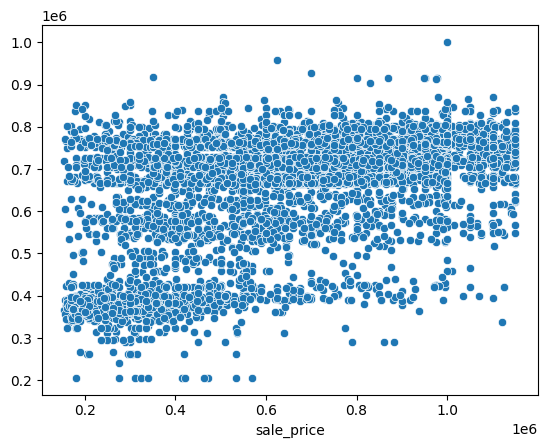

In [15]:
# If these values follow a line = good predictions
sns.scatterplot(x=y_test, y=predictions)

# This doesn't seem like a great result.

#### Creating a DataFrame to Compare Individual `sale_price` with `error_margin`

Let's create a dataframe we can compare the `sale_price` to the prediction results more easily.

### Testing with Imaginary Values

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Implementation|
|4| <bold style="background:yellow;color:black;">Tester Row Values</bold>|
|5| Personal Analysis |
|6|Model Application|
|7| Advanced Tasks|


In [16]:
# Let's test the model with some imaginary variables. 
feature_list = list(df.drop("sale_price", axis=1).columns)

tester_row = {
       'lotarea': 200000, 'bldgarea': 3000, 'unitsres': 15, 'unitstotal': 12,
       'numfloors': 15, 'building_age': 50, 'borough_y_BK': 1, 'borough_y_BX': 0,
       'borough_y_MN': 0, 'borough_y_QN': 0, 'borough_y_SI': 0, 'bldgclass_A0': 0,
       'bldgclass_A1': 0, 'bldgclass_A2': 0, 'bldgclass_A3': 0, 'bldgclass_A4': 1,
       'bldgclass_A5': 0, 'bldgclass_A6': 0, 'bldgclass_A8': 0, 'bldgclass_A9': 0,
       'bldgclass_B1': 0, 'bldgclass_B2': 0, 'bldgclass_B3': 0, 'bldgclass_B9': 0,
       'bldgclass_C0': 0, 'bldgclass_C1': 0, 'bldgclass_C2': 0, 'bldgclass_C3': 0,
       'bldgclass_C4': 0, 'bldgclass_C5': 0, 'bldgclass_C6': 0, 'bldgclass_C7': 0,
       'bldgclass_D0': 0, 'bldgclass_D1': 0, 'bldgclass_D3': 0, 'bldgclass_D4': 0,
       'bldgclass_D6': 0, 'bldgclass_D7': 0, 'bldgclass_E1': 0, 'bldgclass_E9': 0,
       'bldgclass_F4': 0, 'bldgclass_F5': 0, 'bldgclass_F9': 0, 'bldgclass_G1': 0,
       'bldgclass_G2': 0, 'bldgclass_G4': 0, 'bldgclass_G8': 0, 'bldgclass_G9': 0,
       'bldgclass_K1': 0, 'bldgclass_K2': 0, 'bldgclass_K4': 0, 'bldgclass_K7': 0,
       'bldgclass_M1': 0, 'bldgclass_M9': 0, 'bldgclass_O2': 0, 'bldgclass_O5': 0,
       'bldgclass_O7': 0, 'bldgclass_O8': 0, 'bldgclass_S1': 0, 'bldgclass_S2': 0,
       'bldgclass_S3': 0, 'bldgclass_S4': 0, 'bldgclass_S5': 0, 'bldgclass_S9': 0
}

# Convert to pandas format
tester_row = pd.DataFrame([tester_row])

# Get the output/result from the model
# Based on the user's given new data 
result = lm.predict(tester_row)[0]

print()
print(f"Predicted price for this home:")
print(f"$ {round(float(result), 2)}")
print("----------------------------")

# Well, it's a valid number!


Predicted price for this home:
$ 860285.48
----------------------------


---

### Personal Analysis

<br>

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Implementation|
|4| Tester Row Values|
|5|<bold style="background:yellow;color:black;"> Personal Analysis </bold>|
|6|Model Application|
|7| Advanced Tasks|

<br>
<br>
<br>

In my personal analysis, I'll be performing the following process:

|Step|Description|
|---|---|
|1| Create a dataframe which can easily compare the `predicted_price` with the `sale_price`.|
|2| Give some pre-research observations.|
|3| (I do research here)|
|4| Give some post-research observations.|



#### Creating a Dataframe with `predicted_price` and `error_margin`

In [17]:
# Adding a column to the dataframe which predicted the price.

case_df = df
case_df['predicted_price'] = lm.predict(X)

# Creating an error margin column for the price for each row.
case_df["error_margin"] = abs(df["sale_price"] - df['predicted_price'])

# Filtering the dataframe to check out the highest error margins, starting with the highest error_margin.
case_df = df[df['error_margin'] > 500000].sort_values(by='error_margin', ascending=False)
case_df

# Here, we can see some of the extreme cases with high error margins.
# NOTE: `error_margin` and `predicted_price` is at the end of the dataset

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_O7,bldgclass_O8,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S4,bldgclass_S5,bldgclass_S9,predicted_price,error_margin
13872,1078000,313647.0,883265.0,1022.0,1026.0,15.0,75.0,1,0,0,...,0,0,0,0,0,0,0,0,290593.029056,787406.970944
4048,1120000,118122.0,332660.0,330.0,330.0,6.0,73.0,0,0,0,...,0,0,0,0,0,0,0,0,336803.404357,783196.595643
32917,1150000,32400.0,141920.0,146.0,146.0,8.0,76.0,0,0,0,...,0,0,0,0,0,0,0,0,393777.036863,756222.963137
23675,1148000,10000.0,52454.0,43.0,43.0,6.0,93.0,0,0,0,...,0,0,0,0,0,0,0,0,394033.335056,753966.664944
12253,1150000,11750.0,49158.0,39.0,39.0,6.0,99.0,1,0,0,...,0,0,0,0,0,0,0,0,403515.418576,746484.581424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16331,228000,2500.0,956.0,1.0,1.0,2.0,100.0,1,0,0,...,0,0,0,0,0,0,0,0,728935.667319,500935.667319
7592,883742,5130.0,27550.0,28.0,28.0,5.0,94.0,0,1,0,...,0,0,0,0,0,0,0,0,383163.020856,500578.979144
32458,190775,3625.0,3960.0,2.0,4.0,2.0,94.0,0,0,0,...,0,0,0,0,0,0,0,0,691235.961763,500460.961763
28776,260000,4900.0,1748.0,2.0,2.0,2.0,75.0,0,0,0,...,0,0,0,0,0,0,0,0,760279.410568,500279.410568


<h3>Pre-Research Observations</h3>
<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

In the above cell's dataframe output, notice that of these error margins are very high (300k-500k), which suggest the following:

* A flaw with the approach of the data handling/cleaning.
* An issue with the data
* A problem with the model we're using

Let's try to rule out some of these reasons. In the above cell's Dataframe, we're looking for common denominators(relationships) in these high `error_margin` cases.
 In this case, the only thing I'm noticing is that we can see `bldgclass_D4` being `True` is quite common.

####  Scatterplot which shows one problem:

 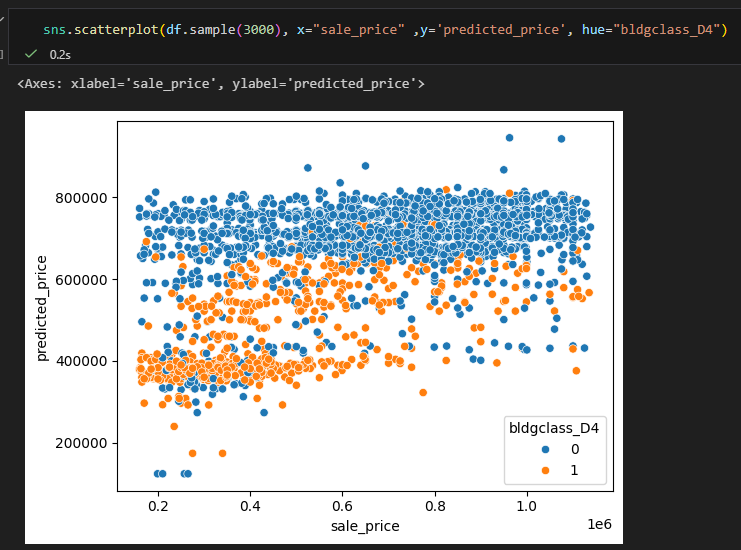


The `bldgclass` D4 value has a remarkably high variance with an often overpredicted value, leading me to believe there is some feature which exists that we do not have.

Regardless, I'll let this be a learning experience and move forward with the project. In the more advanced courses I can likely troubleshoot this a bit better.

<h3>Post-Research Observations: </h3>

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<i>

I experimented by putting in a new model, `RandomForestRegressor` to see if it would give me improvements.
The results for `RandomForestRegressor` were only marginally better than `LinearRegression`. 

</i>

<br>


|Random Forest Regressor Scatterplot (y-test, prediction)| Random Forest Regressor Performance Metrics|
|---|---|
|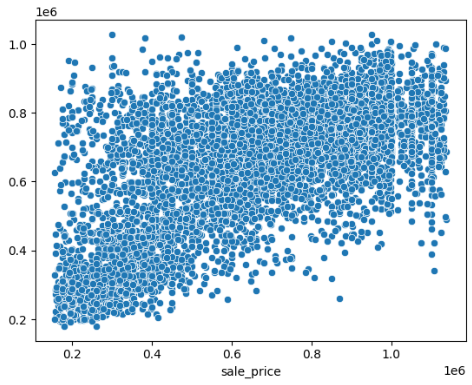|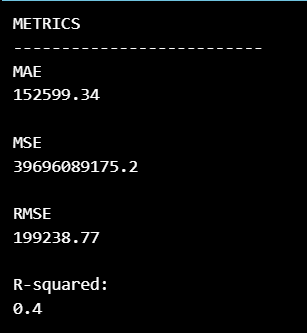|

I've done some research and some work related to WHY the performance metrics are so low with this particular dataset.

<br>
<i>
<strong style='color:orange ; background-color:black;'>
  TLDR: It's a dataset issue.
</strong></i>

<b>Reasoning:</b>

<i>
<b>We're missing a key feature when it comes to NYC housing -- Maintenance contracts.</b>

 Just like in Finland,
many homes are part of housing associations or come with a maintenance contract, which affect the price HEAVILY. These maintenance contracts 
correlate negatively with the sales price of the home/apartment (higher maintenance cost, lower home price).
 Look at the example below so you get an idea of what I mean. Assume that these two homes are the same just with different maintenance contracts/costs.
But say that they have different maintenance contracts.

</i>

<b>Example:</b>

|House|House Price| Maintenance Cost/month|
|---|---|---|
|1| 400,000| 1,200|
|2| 1,000,000| 300|

<br>
<i>

`bldgclass_D4` is an apartment co-op building class, which are homes that are notorious for having high variance in these maintenance fees. 

Therefore, since price of the home is heavily correlated by the maintenance cost and since we do not have this `maintenance_costs/mo` in the dataset and
cannot easily retrieve it, the dataset is likely inherently flawed no matter how much optimization I use. Another complication is that this dataset isn't home-prices, but <b>housing lot </b> prices, which is likely more complicated because
it means both individual homes and entire apt complexes are in the dataset. Quite frankly, that made the title of this dataset quite misleading and I'll be picking my datasets more carefully from now on.

</i>

<b>Sources:</b> 

<i>
If you'd like to see how I made reached this conclusion:
</i>
<br>
<br>

|Number|Source|
|---|---|
|1|[A forum discussing the maintenance cost & resale price](https://streeteasy.com/talk/discussion/40799-should-i-be-scared-away-by-high-maintenance-fee)
|2|[A paper that not-so-briefly discusses the complexity of the problem](https://arxiv.org/pdf/2007.01171)

</div>


---

#### Model Application

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Implementation|
|4| Tester Row Values|
|5| Personal Analysis|
|6| <bold style="background:yellow;color:black;">Model Application</bold>|
|7| Advanced Tasks|

In this model application, we'll create a <strong> GUI that allows the user to enter NYC home characteristics and give a predicted lot price</strong>
and parameters for their home and it will spit out a predicted price. We'll be using `gradio` for this application. I chose this app because it has webdev-like features
and we can run it as the output in a jupyter-notebook cell(nice and quick to test.).

### <strong style='color:red ; background-color:black;'>FULL DISCLOSURE: I AM USING AI.</strong>

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

#### What is AI generated?

_The two lists at the beginning. I couldn't be bothered to write them myself._
<br>


#### LLM:

_ChatGPT 5.0_ 

</div>


In [18]:
import gradio as gr


# We use these to create key-value pairs with conditional logic. 
bldg_classes = ['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A8', 'A9',
            'B1', 'B2', 'B3', 'B9','C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'D0', 
            'D1', 'D3', 'D4', 'D6', 'D7', 'E1', 'E9','F4', 'F5', 'F9','G1', 'G2', 'G4', 
            'G8', 'G9', 'K1', 'K2', 'K4', 'K7', 'M1', 'M9', 'O2', 'O5', 'O7', 'O8', 'S1',
            'S2', 'S3', 'S4', 'S5', 'S9']

boroughs = ["BK", "BX", "MN", "QN", "SI"]

# This function interprets the values submitted from the user in the gradio app and predicts the result.
def predict(borough, bldg_class, lotarea, bldgarea, 
    unitsres, unitstotal, numfloors, building_age):

    # First, we're going to create a dict. Notice it's incomplete! See the next step.
    tester_row = {
    'lotarea': lotarea, 'bldgarea': bldgarea,
    'unitsres': unitsres, 'unitstotal': unitstotal,
    'numfloors': numfloors, 'building_age': building_age,
    }

    # Next, this loop will add all the boroughs in the `tester_row` dictionary...

    # If the user-selected borough matches the bourough iteration in the list...
    # give a value of 1. Otherwise, give the value 0.
    # Then, add it as a key:value pair in the `tester_row` dict.
    for b in boroughs:
        borough_key = f"borough_y_{b}"

        if b == borough:
            tester_row[borough_key] = 1
        else:
            tester_row[borough_key] = 0

    # Same as above, except classes edition, baby!
    for c in bldg_classes:
        bldgclass_key = f"bldgclass_{c}"

        if c == bldg_class:
            tester_row[bldgclass_key] = 1
        else:
            tester_row[bldgclass_key] = 0
  
    # Transform the dict into a dataframe, and predict the user's output.
    tester_row = pd.DataFrame([tester_row])
    result = lm.predict(tester_row)[0]
    result = result.round(2)
    
    return result

# Use Gradio Blocks to create a GUI! This should show up in the output cell.
# NOTE: Click the `local URL` link for it to appear in your web-browser, if you prefer. 

with gr.Blocks() as house_lot_prediction:

    gr.Markdown("## NYC Home Price Predictor")
    gr.Markdown("### Enter Property Details")

    # Input options
    select_borough = gr.Dropdown(choices=boroughs, label="Which Borough do you live in?")
    select_class = gr.Dropdown(choices=bldg_classes, label="What building class does your lot have?")
    select_lotarea = gr.Number(label="How big is your plot of land? (freedom units please)")
    select_bldgarea = gr.Number(label="How much building area is on your plot of land? (freedom units please)")
    select_unitsres = gr.Number(label="How many residential units are on your plot of land?")
    select_unitstotal = gr.Number(label="How many residential and non residential units are on your plot of land?")
    select_numfloors = gr.Slider(label="What's the maximum number of floors on your plot of land?", minimum=1, maximum=104)
    select_building_age =gr.Slider(label="How old, on average, is your buildings?", minimum=0, maximum=250)

    gr.Markdown("### Prediction")

    # Prediction output and submit button
    outputs = gr.Number(label="Home Price")
    submit = gr.Button("Predict Price")

    # Click action functionality
    submit.click(
        fn=predict,
        inputs=[
            select_borough, select_class, select_lotarea, select_bldgarea,
            select_unitsres, select_unitstotal, select_numfloors, select_building_age
        ],
        outputs=outputs
    )

house_lot_prediction.launch()

# If you don't see the submit button, keep scrolling. It's there!

c:\Users\OWNER\Intro_ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---

## Advanced Tasks

|Task|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Experiment with polynomial and curve fitting features of `scikit-learn` with any dataset. Explain your findings in your Jupyter notebook, and analyze how useful they are.</bold>|
|2|Write down the multiple linear regression formula of your model by using the `intercept-` and `coeff–` variables in your model `–object`.|
|3|You can also consider using other regressors like `CatBoostRegressor` which allows you to use other types of data than numbers without transformations. Write down your experiences with this regressor.|

<br>

### Adv. Task 1 -- Polynomial, Curve-fitting feature experimentation


<i> New notebook for this </i>



### Adv. Task 2 -- Print the Poly-Linear Regression

|Task|Description|
|---|---|
|1|Experiment with polynomial and curve fitting features of `scikit-learn` with any dataset. Explain your findings in your Jupyter notebook, and analyze how useful they are.|
|2|<bold style="background:yellow;color:black;"> Write down the multiple linear regression formula of your model by using the `intercept-` and `coeff–` variables in your model `–object`.</bold>|
|3|You can also consider using other regressors like `CatBoostRegressor` which allows you to use other types of data than numbers without transformations. Write down your experiences with this regressor.|

This shouldn't be terribly hard, especially since the intercept and coefficient are literally given as 
`intercept-` and `coeff-`. The only REAL issue is that we have so many features that we'll need to creative with naming them!

In [19]:
# First, we'll turn the coefficients into a list.
# This makes it easier to iterate over.
coefs_list = coefs.tolist()

# This will allow us to make subscripts.
# NOTE: These will only be used in the print section.
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")

# This string will contain the formula.
regression_string = "y = "

# This loop will add each variable and weight to the string.
# The `enumerate` in the loop will let me call the VALUE and the INDEX.
# The index will be used to generate new variable names.
# IE: X₁ X₂ X₃ (as X_1, X_2, X_3)
for  index, coef in enumerate(coefs_list):
    
    index += 1
    index = index.translate(sub)
    coef = round(coef,2)
    regression_string += f"{coef}x_{index} + " 

regression_string += str(intercept)
print(regression_string)



AttributeError: 'int' object has no attribute 'translate'